In [1]:
import json
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [15]:
# Specify metadata file and data file paths
json_file = 'metadata.json'
data_file_path = '../Data_Download_Test/controllers/2024-05-09/controller_p1_0000_00.mat'

# Specify spectgrogram parameters
fft_window = 512
time_window = 512

# The index of signal to visualize - could be changed later
sig_idx = 0

### ------------ No need to change the code below this line ------------

In [9]:
# Display metadata information

with open(json_file) as cur_file:
    metadata = json.load(cur_file)

print('----------------------------------------')
print('Metadata:')
for k in metadata.keys():
    print(k, ':', metadata[k])

print('----------------------------------------')

# Transmitter ID dictionary
id_dict = dict()
for k_idx in range(len(metadata['DroneID'])):
    id_dict[metadata['DroneIndex'][k_idx]] = metadata['DroneID'][k_idx]
    
# Spectrogram parameters
fs = metadata['SamplingRate']
spec = dict()
spec['fs'] = fs
spec['fft_window'] = fft_window
spec['time_window'] = time_window

----------------------------------------
Metadata:
SamplingRate : 50000000.0
Signal_Time_Duration : 1
Samples_Per_Signal : 50000000.0
Signals_Per_File : 1
DroneID : ['drone_1', 'drone_2', 'drone_3', 'drone_4', 'controller_1', 'controller_2', 'controller_3', 'controller_4', 'controller_1_2', 'controller_1_3', 'controller_1_4', 'controller_2_3', 'controller_2_4', 'controller_3_4', 'controller_1_2_3', 'controller_1_2_4', 'controller_1_3_4', 'controller_2_3_4', 'controller_1_2_3_4', 'none']
DroneIndex : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Rx : USRP B205mini-i
CenterFrequency : 2443500000.0
Bandwidth : 50000000.0
----------------------------------------


In [10]:
def create_spectrogram(iq_data, fft_window, normalize=False):
    """
    Generate spectrograms of iq_data with specficied fft_window size.
    """
    # Hamming window
    iq_data = scipy.signal.windows.hamming(fft_window)*iq_data
    
    # Generate the spectrogram
    fft_data = np.fft.fftshift(np.fft.fft(iq_data, fft_window, axis=-1) / fft_window, axes=-1)
    spectrogram = 20 * np.log10(np.abs(fft_data))

    # Normalization
    if normalize:
        spectrogram = (spectrogram - np.min(spectrogram, axis=(1, 2), keepdims=True))/(np.max(spectrogram, axis=(1, 2), keepdims=True) - np.min(spectrogram, axis=(1, 2), keepdims=True) + 1e-10)
    
    return spectrogram

def create_dataset(loaded_data, spec, id_dict, normalize=False):
    """
    Create a dictionary of dataset which includes:
    1. Spectrgrams with the specified parameters, and
    2. Converted labels in the format of bounding boxes
    """
    fft_window = spec['fft_window']
    time_window = spec['time_window']
    fs = spec['fs']

    iq_data = np.reshape(loaded_data['data'], (1, -1))
    len_signal_segment = fft_window * time_window
    num_signal_segment = iq_data.shape[-1] // len_signal_segment
    num_transmissions = np.zeros((num_signal_segment,))
    
    # Crop and reshape the IQ data.
    remaining = iq_data.shape[-1] % (fft_window*time_window)
    iq_data = np.reshape(iq_data[..., :iq_data.shape[-1]-remaining], (-1, time_window, fft_window))
    # Generate spectrograms.
    spectrograms = create_spectrogram(iq_data, fft_window, normalize)
    
    dataset = dict()
    dataset['data'] = spectrograms
    
    # Load original time-domain labels (matlab -> python indices requires -1).
    start_idx = np.reshape(loaded_data['start']-1, (-1))
    end_idx = np.reshape(loaded_data['end']-1, (-1))
    # Convert labels into bounding boxes.
    xs = np.reshape(loaded_data['fc'], (-1,))/ fs * fft_window + fft_window/2
    ws = np.reshape(loaded_data['bw'], (-1,)) / fs * fft_window
    ids = np.reshape(loaded_data['id'], (-1,))
    
    # Placeholders for converted labels.
    all_start_idx = np.zeros((start_idx.shape[0] + num_signal_segment*2 + 1,)) - 1
    all_end_idx = np.zeros((start_idx.shape[0] + num_signal_segment*2 + 1,)) - 1
    dataset['x'] = np.zeros((start_idx.shape[0] + num_signal_segment*2 + 1,))
    dataset['w'] = np.zeros((start_idx.shape[0] + num_signal_segment*2 + 1,))
    dataset['id'] = np.zeros((start_idx.shape[0] + num_signal_segment*2 + 1,)) 
    signal_segment_idx_list = np.zeros((start_idx.shape[0] + num_signal_segment*2 + 1,)) 
    
    signal_segment_idx = 0 # spectrogram index in processed dataset dictionary
    transmission_idx = 0 # transmission index in processed dataset dictionary
    cur_idx = 0 # transmission index in .mat file
    start_from_prev = False
    
    while cur_idx < start_idx.shape[0]:        
        if start_from_prev:
            # If a signal is split into two spectrograms, the second spectrogram starts with a signal.
            all_start_idx[transmission_idx] = 0
        else:
            # Compute the start index in current spectrogram.
            cur_start = start_idx[cur_idx] - signal_segment_idx*len_signal_segment
            if cur_start >= 0:
                # Transmissions in the current spectrogram.
                if cur_start < len_signal_segment:
                    # Save the start index in current spectrogram.
                    all_start_idx[transmission_idx] = cur_start
                else:
                    # No valid signal in current spectrogram.
                    signal_segment_idx += 1
                    continue
            else:
                # Remaining transmissions in a previous spectrogram
                while cur_start < 0:
                    if signal_segment_idx == 0:
                        raise RuntimeError('Transmission start_time earlier than 0.')
                    signal_segment_idx -= 1
                    cur_start = start_idx[cur_idx] - signal_segment_idx*len_signal_segment
                all_start_idx[transmission_idx] = cur_start
        
        if signal_segment_idx >= num_signal_segment:
            # Ignore the data at the end if it's not enough to generate a spectrogrm of the specified size.
            start_from_prev = False
            cur_idx += 1
            continue
        
        # Save other labels accordingly
        dataset['x'][transmission_idx] = xs[cur_idx]
        dataset['w'][transmission_idx] = ws[cur_idx]
        dataset['id'][transmission_idx] = ids[cur_idx]
        signal_segment_idx_list[transmission_idx] = signal_segment_idx
        
        # Compute the end index of the current signal.
        cur_end = end_idx[cur_idx] - signal_segment_idx*len_signal_segment

        if cur_end < len_signal_segment:
            # If the signal ends within the current spectrogram, check the length of the valid signal.
            start_from_prev = False
            if cur_end - all_start_idx[transmission_idx] < fft_window:
                # Ignore the signal if it is too short.
                all_start_idx[transmission_idx] = -1
                cur_idx += 1
                continue
            else:
                all_end_idx[transmission_idx] = cur_end
                cur_idx += 1
                num_transmissions[signal_segment_idx] += 1
        else:
            # If the signal does not end within the current spectrogram,
            # save the last index as the end and continue to the next spectrogram.
            all_end_idx[transmission_idx] = len_signal_segment - 1
            num_transmissions[signal_segment_idx] += 1
            start_from_prev = True
            signal_segment_idx += 1

        transmission_idx += 1
        
    # Return the dataset.
    total_transmissions = np.sum(num_transmissions).astype(int)
    all_start_idx = all_start_idx[:total_transmissions]
    all_end_idx = all_end_idx[:total_transmissions]

    dataset['y'] = (all_start_idx + all_end_idx) /2 / fft_window
    dataset['h'] = (all_end_idx - all_start_idx) / fft_window
    dataset['x'] = dataset['x'][:total_transmissions]
    dataset['w'] = dataset['w'][:total_transmissions]
    dataset['id'] = dataset['id'][:total_transmissions]
    
    signal_segment_idx_list = signal_segment_idx_list[:total_transmissions]
    signal_segment_idx_list = np.argsort(signal_segment_idx_list)
    
    dataset['y'] = dataset['y'][signal_segment_idx_list]
    dataset['h'] = dataset['h'][signal_segment_idx_list]
    dataset['x'] = dataset['x'][signal_segment_idx_list]
    dataset['w'] = dataset['w'][signal_segment_idx_list]
    dataset['id'] = dataset['id'][signal_segment_idx_list]

    dataset['fft_window'] = fft_window
    dataset['drone_id_dict'] = id_dict
    dataset['num_transmissions'] = num_transmissions
    
    return dataset

def plot_spectrogram(dataset, spec, sig_idx, id_dict=None):
    """
    Plot the spectrogram of the specified signal (sig_idx) in the dataset.
    Set id_dict to None to turn off the transmitter id.
    """
    
    # Plotting parameters.
    fontsize = 20
    figsize = (10,8)
    n_ticks = 5
    freq_unit = 1e6
    time_unit = 1e6
    fs = spec['fs']
    fft_window = spec['fft_window']
    freq_resolution = fs/fft_window
    time_resolution = fft_window/fs
    
    # Locate the spectrogram data and labels in the dataset.
    spectrogram = dataset['data'][sig_idx]
    num_transmissions = int(dataset['num_transmissions'][sig_idx])
    if sig_idx > 0:
        prev_transmissions = int(np.sum(dataset['num_transmissions'][:sig_idx]))
    else:
        prev_transmissions = 0
    x = dataset['x'][prev_transmissions:prev_transmissions+num_transmissions]
    w = dataset['w'][prev_transmissions:prev_transmissions+num_transmissions]
    y = dataset['y'][prev_transmissions:prev_transmissions+num_transmissions]
    h = dataset['h'][prev_transmissions:prev_transmissions+num_transmissions]

    # Plot the spectrogram.
    vmin = np.min(spectrogram)
    vmax = np.max(spectrogram)
    plt.figure(figsize=figsize)
    img = plt.imshow(spectrogram, interpolation='nearest', cmap='viridis',
                     aspect='auto', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(img)
    cbar.ax.tick_params(labelsize=fontsize)
    cbar.ax.set_ylabel(ylabel='Power (dB/Hz)', fontsize=fontsize)
    plt.tick_params(axis='both', which='major', labelsize=fontsize)
    plt.xticks(np.arange(0, spectrogram.shape[1]+1, int(spectrogram.shape[1]/n_ticks)),
               (np.arange(0, fs/freq_unit+1, fs/n_ticks/freq_unit)-fs/2/freq_unit+2440).astype(int))
    plt.yticks(np.arange(0, spectrogram.shape[0]+1, int(spectrogram.shape[0]/n_ticks)),
               ["{:.1f}".format(idx) for idx in np.arange(0,
                                                          spectrogram.shape[0]*time_resolution*1e3+1,
                                                          spectrogram.shape[0]*time_resolution/n_ticks*1e3)])
    plt.xlabel('Frequency (MHz)' + '\n' + ' (frequency resolution {:.1f} kHz)'.
               format(fs/(fft_window * 1000)), fontsize=fontsize)
    plt.ylabel('Time (ms) ' + '\n' + ' (time resolution ' + r'$t_{s} = $' +
               '{} usec'.format(fft_window/fs * time_unit) + ')', fontsize=fontsize)

    # Plot bounding boxes.
    x = x - w/2
    y = y - h/2
    ids = dataset['id'][prev_transmissions:prev_transmissions+num_transmissions]

    for box_idx in range(x.shape[0]):
        plt.gca().add_patch(Rectangle((x[box_idx], y[box_idx]), w[box_idx], h[box_idx],
                                        edgecolor='red', facecolor='none', lw=2))
        if id_dict == None:
            pass
        else:
            plt.text(x[box_idx], y[box_idx], id_dict[ids[box_idx]], c='r', fontsize=fontsize)

    plt.tight_layout()
    plt.show()
    

    return None

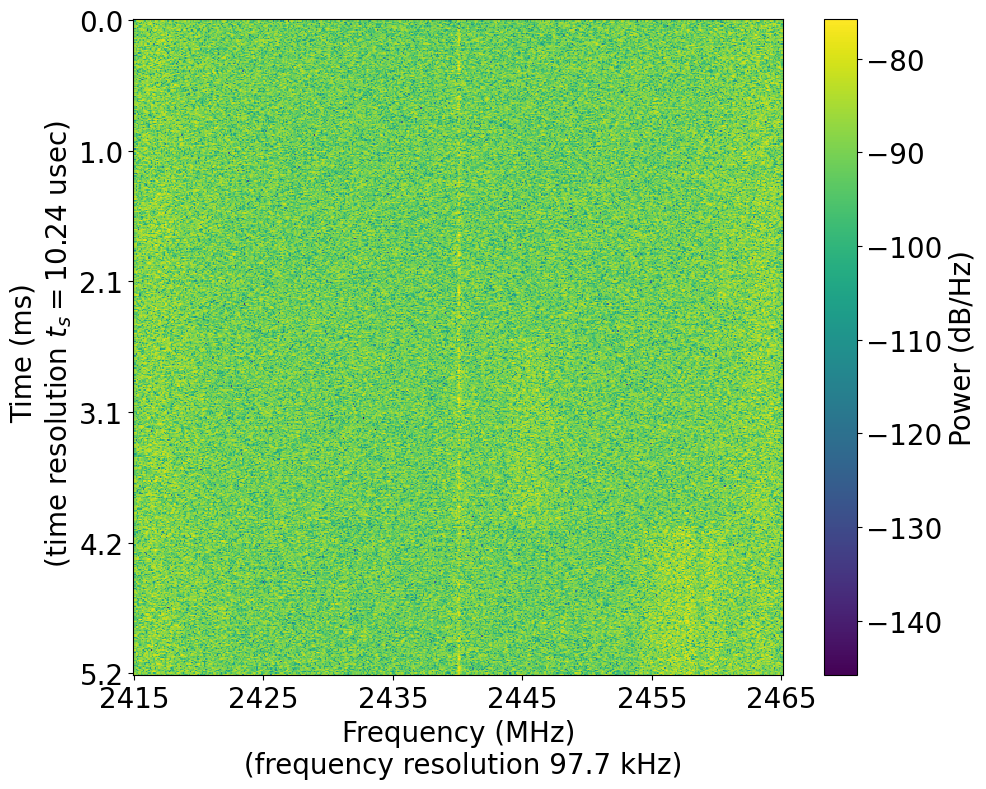

In [16]:
# Load data.
loaded_data = scipy.io.loadmat(data_file_path)
# Convert to spectrograms.
dataset = create_dataset(loaded_data, spec, id_dict, normalize=False)
# Plot a selected spectrogram - set id_dict to None to turn off transmitter id.
plot_spectrogram(dataset, spec, sig_idx, id_dict=id_dict)